# 3. Visualize parquet (cablelabs2 style)

Same visualizations as **cablelabs2** `visualize.py`: data summary, **time series** (numeric column over time), **Frequency vs Trace Max heatmap**, **distribution** histogram, **correlation heatmap**, and **data preview** table. Uses one parquet file from `work_dir/raw_data` (or set path below).

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
# Parquet file path (try work_dir/raw_data, or set to a specific file)
parquet_path = Path("work_dir/raw_data")
if not parquet_path.exists():
    parquet_path = Path("../work_dir/raw_data")
parquet_files = sorted(parquet_path.glob("*.parquet")) if parquet_path.is_dir() else []
if parquet_files:
    single_parquet = parquet_files[0]  # pick first; change index or set single_parquet = Path("path/to/file.parquet")
else:
    single_parquet = Path("work_dir/raw_data/Band_195MHz_WO_meta_20260201_0037.parquet")  # fallback

df = pd.read_parquet(single_parquet)
if "timestamp" in df.columns:
    if df["timestamp"].min() > 1e9:
        df["datetime"] = pd.to_datetime(df["timestamp"], unit="s")
    else:
        df["datetime"] = pd.to_datetime(df["timestamp"])

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if "datetime" in df.columns and "timestamp" in numeric_cols:
    numeric_cols.remove("timestamp")
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
time_col = "datetime" if "datetime" in df.columns else None
if time_col is None:
    for c in ["timestamp", "date", "time"]:
        if c in df.columns:
            time_col = c
            break
y_col = "trace_max" if "trace_max" in numeric_cols else (numeric_cols[0] if numeric_cols else None)
sample_size = 50000 if len(df) > 50000 else "all"

print(f"Loaded: {single_parquet}")
print(f"Rows: {len(df):,}, Columns: {len(df.columns)}")
print(f"Numeric: {len(numeric_cols)}, Categorical: {len(categorical_cols)}")

Loaded: ../work_dir/raw_data/Band_195MHz_WO_meta_20260201_0037.parquet
Rows: 5,017, Columns: 5
Numeric: 3, Categorical: 0


## Data summary

Total rows, columns, numeric/categorical counts (same as cablelabs2 dashboard).

In [3]:
print(f"Total Rows: {len(df):,}")
print(f"Total Columns: {len(df.columns)}")
print(f"Numeric Columns: {len(numeric_cols)}")
print(f"Categorical Columns: {len(categorical_cols)}")

Total Rows: 5,017
Total Columns: 5
Numeric Columns: 3
Categorical Columns: 0


## Time series: Y over time

Plot selected numeric column (default `trace_max`) over time. Sampled if > 50k points (cablelabs2 default).

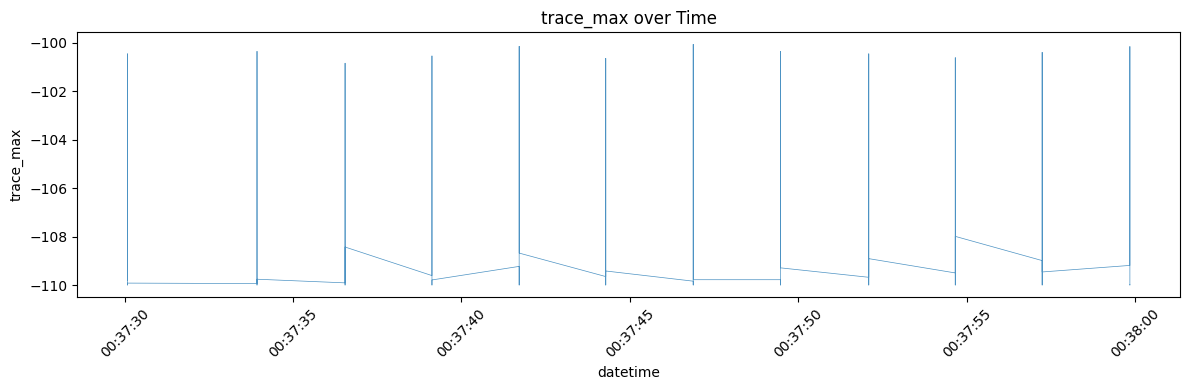

In [4]:
if time_col and y_col:
    plot_df = df.copy()
    if sample_size != "all":
        n = int(sample_size)
        if len(plot_df) > n:
            plot_df = plot_df.sample(n=n).sort_values(time_col)
    plot_df = plot_df.sort_values(time_col)
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(plot_df[time_col], plot_df[y_col], linewidth=0.5, alpha=0.8)
    ax.set_title(f"{y_col} over Time")
    ax.set_xlabel(time_col)
    ax.set_ylabel(y_col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No time column or Y column for time series.")

## Frequency vs Trace Max heatmap

2D histogram of frequency (Hz) vs trace_max (counts per bin). Same as cablelabs2: 100×100 bins, Viridis.

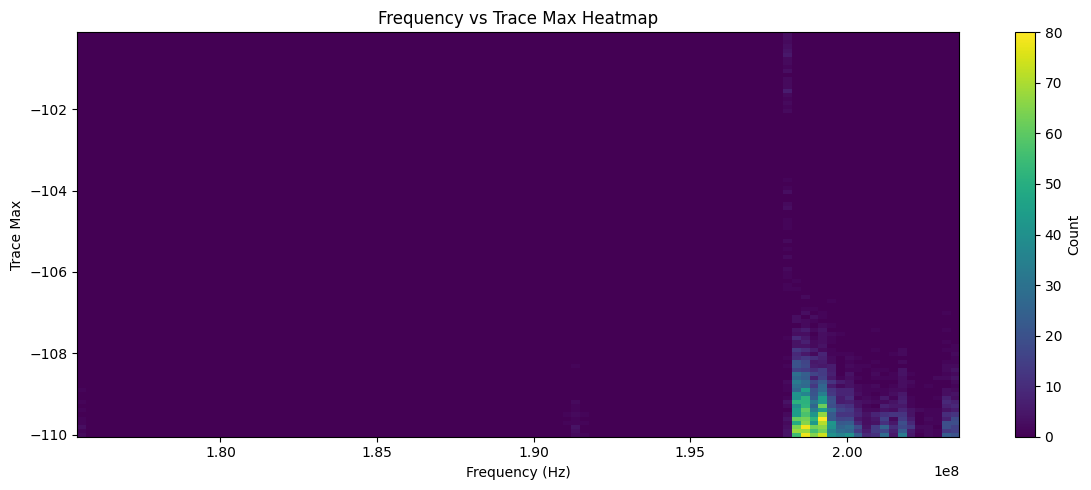

In [ ]:
if "freqs" in df.columns and "trace_max" in df.columns:
    freq_bins, trace_bins = 100, 100
    hist, xedges, yedges = np.histogram2d(df["freqs"].values, df["trace_max"].values, bins=[freq_bins, trace_bins])
    fig, ax = plt.subplots(figsize=(12, 5))
    im = ax.pcolormesh(xedges[:-1], yedges[:-1], hist.T, cmap="viridis")
    plt.colorbar(im, ax=ax, label="Count")
    ax.set_title("Frequency vs Trace Max Heatmap")
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Trace Max")
    plt.tight_layout()
    plt.show()
else:
    print("Need 'freqs' and 'trace_max' for heatmap.")

## Distribution

Histogram of selected numeric column (default `trace_max`). Sampled if large (cablelabs2 behavior).

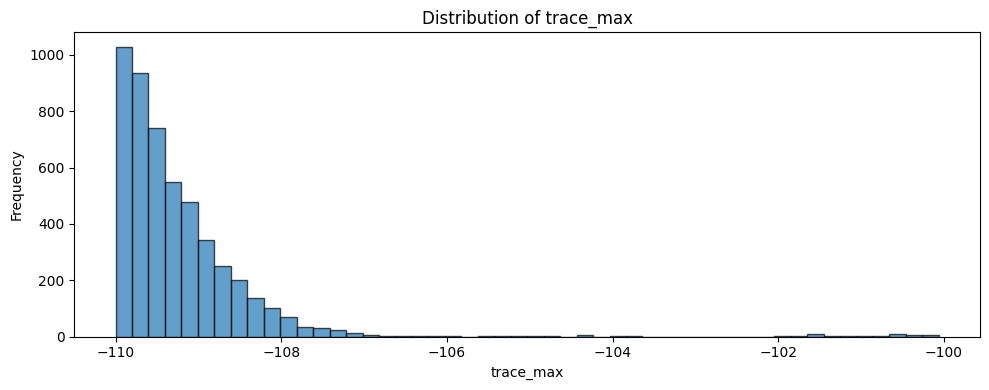

In [6]:
if y_col:
    plot_df = df.copy()
    if sample_size != "all":
        n = int(sample_size)
        if len(plot_df) > n:
            plot_df = plot_df.sample(n=n)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(plot_df[y_col].dropna(), bins=50, edgecolor="black", alpha=0.7)
    ax.set_title(f"Distribution of {y_col}")
    ax.set_xlabel(y_col)
    ax.set_ylabel("Frequency")
    plt.tight_layout()
    plt.show()
else:
    print("No numeric column for distribution.")

## Correlation heatmap

Correlation matrix of numeric columns (RdBu, same as cablelabs2).

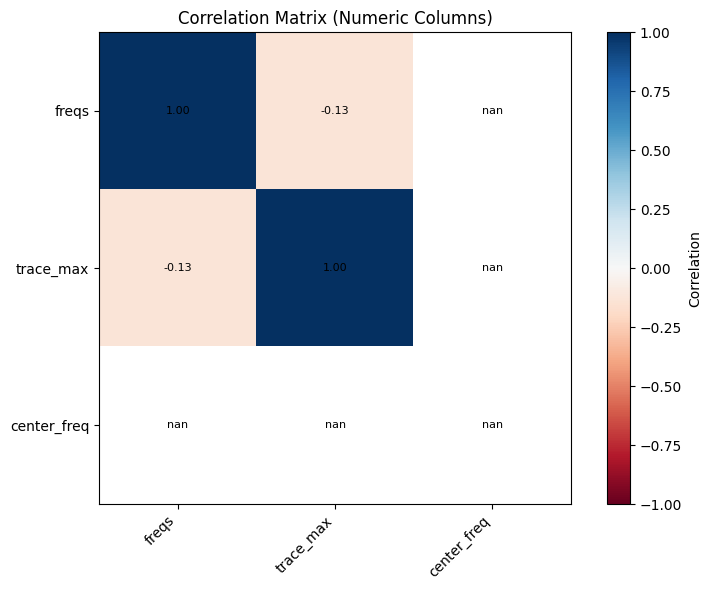

In [7]:
if len(numeric_cols) > 1:
    corr = df[numeric_cols].corr()
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(corr.values, cmap="RdBu", vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(corr.index)))
    ax.set_yticklabels(corr.index)
    for i in range(len(corr)):
        for j in range(len(corr)):
            ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=8)
    plt.colorbar(im, ax=ax, label="Correlation")
    ax.set_title("Correlation Matrix (Numeric Columns)")
    plt.tight_layout()
    plt.show()
else:
    print("Need at least 2 numeric columns for correlation heatmap.")

## Data preview

First 100 rows (same as cablelabs2 data table).

In [8]:
display(df.head(100))

,timestamp,freqs,trace_max,center_freq,datetime
0,1.769906e+09,1.915234e+08,-109.80,195000000,2026-02-01 00:37:30.084606886
1,1.769906e+09,1.915258e+08,-109.85,195000000,2026-02-01 00:37:30.084606886
2,1.769906e+09,1.916894e+08,-109.96,195000000,2026-02-01 00:37:30.084606886
3,1.769906e+09,1.983032e+08,-105.16,195000000,2026-02-01 00:37:30.084606886
4,1.769906e+09,1.983056e+08,-101.53,195000000,2026-02-01 00:37:30.084606886
...,...,...,...,...,...
95,1.769906e+09,1.987451e+08,-109.91,195000000,2026-02-01 00:37:30.084606886
96,1.769906e+09,1.987475e+08,-109.98,195000000,2026-02-01 00:37:30.084606886
97,1.769906e+09,1.987548e+08,-109.70,195000000,2026-02-01 00:37:30.084606886
98,1.769906e+09,1.987670e+08,-109.91,195000000,2026-02-01 00:37:30.084606886
